XOR Gate MLP (Training until perfect convergence...)
Epoch 0

Hidden Layer Weights
[[-0.24357627  0.8981513   0.45631541  0.19151711]
 [-0.68151451 -0.69506834 -0.8865485   0.72798917]]

Hidden Layer Bias
[ 0.21610532  0.40620249 -0.96854799  0.93124572]

Output Layer Weights
[[ 0.70203167]
 [-0.52378599]
 [-0.61314315]
 [-0.5639759 ]]

Output Layer Bias
[-0.30542284]

Epoch 100

Hidden Layer Weights
[[-0.16229823  0.97430416  0.19123503  0.05150788]
 [-0.68642527 -0.85151951 -0.85614754  0.60981771]]

Hidden Layer Bias
[ 0.24848666  0.40348527 -1.04362785  0.82540416]

Output Layer Weights
[[ 0.79245445]
 [-0.46267017]
 [-0.34011528]
 [-0.17299642]]

Output Layer Bias
[0.11422467]

Epoch 200

Hidden Layer Weights
[[-0.09298174  1.1944888   0.01533323 -0.0423134 ]
 [-0.74899395 -1.003335   -0.86065973  0.50892653]]

Hidden Layer Bias
[ 0.19831762  0.56166554 -1.0823914   0.73172064]

Output Layer Weights
[[ 0.75535983]
 [-0.67616427]
 [-0.2515759 ]
 [-0.10177197]]

Output Layer Bias
[0

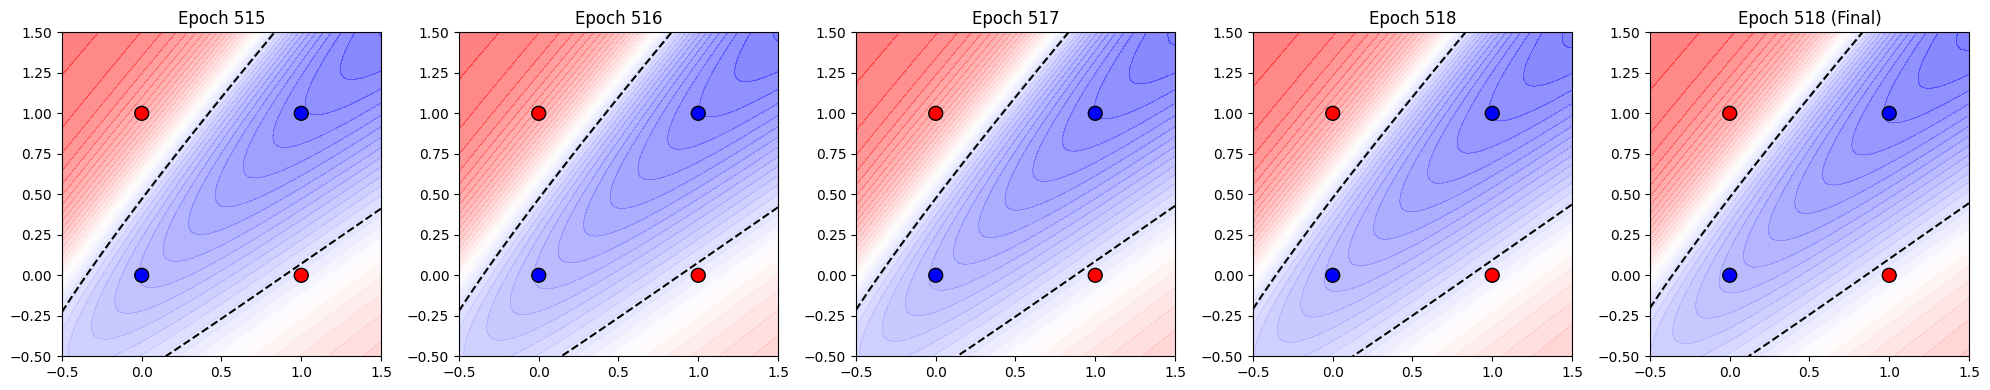

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# 1. Define the Activation Function (Sigmoid) and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


# 2. Helper function to plot decision boundaries
def plot_decision_boundaries(history, X, y):

    # Create a figure with 5 subplots side-by-side
    fig, axes = plt.subplots(
        1,
        len(history),
        figsize=(4 * len(history), 4)
    )

    if len(history) == 1:
        axes = [axes]

    for idx, (epoch_label, W1, b1, W2, b2) in enumerate(history):
        ax = axes[idx]

        # Create a meshgrid (a dense grid of points from -0.5 to 1.5)
        xx, yy = np.meshgrid(
            np.linspace(-0.5, 1.5, 100),
            np.linspace(-0.5, 1.5, 100)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]

        # Do a Forward Pass on the entire grid to get predictions
        z1 = np.dot(grid, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        # Reshape the output to match the grid shape
        a2 = a2.reshape(xx.shape)

        # Plot decision boundary probability gradients (red/blue)
        ax.contourf(
            xx,
            yy,
            a2,
            levels=50,
            cmap='bwr',
            alpha=0.5
        )

        # Plot the hard threshold
        # (the exact decision boundary line at 0.5)
        ax.contour(
            xx,
            yy,
            a2,
            levels=[0.5],
            colors='black',
            linestyles='dashed'
        )

        # Plot the actual XOR data points on top
        ax.scatter(
            X[:, 0],
            X[:, 1],
            c=y.flatten(),
            cmap='bwr',
            edgecolor='k',
            s=100
        )

        ax.set_title(f"Epoch {epoch_label}")
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)

    plt.tight_layout()
    plt.show()


# 3. Define the MLP Training Function
def train_mlp_until_convergence(
    X,
    y,
    gate_name,
    lr=0.5,
    max_epochs=10000
):

    np.random.seed(42)

    W1 = np.random.uniform(-1, 1, (2, 4))
    b1 = np.random.uniform(-1, 1, (1, 4))

    W2 = np.random.uniform(-1, 1, (4, 1))
    b2 = np.random.uniform(-1, 1, (1, 1))

    # We will store the states of the last 5 epochs here
    history = deque(maxlen=5)

    print("=" * 60)
    print(f"{gate_name} (Training until perfect convergence...)")
    print("=" * 60)

    epoch = 0

    while epoch < max_epochs:

        error_count = 0
        predictions = []

        # Save a copy of the weights BEFORE the updates for this epoch
        history.append(
            (
                epoch,
                W1.copy(),
                b1.copy(),
                W2.copy(),
                b2.copy()
            )
        )

        for i in range(len(X)):

            x_i = X[i:i + 1]
            y_i = y[i:i + 1]

            # FORWARD PASS
            z1 = np.dot(x_i, W1) + b1
            a1 = sigmoid(z1)

            z2 = np.dot(a1, W2) + b2
            a2 = sigmoid(z2)

            prediction = (
                1 if a2[0, 0] >= 0.5 else 0
            )

            predictions.append(prediction)

            if prediction != y_i[0, 0]:
                error_count += 1

            # BACKWARD PASS
            error = y_i - a2

            d_a2 = (
                error
                * sigmoid_derivative(a2)
            )

            error_hidden = d_a2.dot(W2.T)

            d_a1 = (
                error_hidden
                * sigmoid_derivative(a1)
            )

            W2 += (
                a1.T.dot(d_a2)
                * lr
            )

            b2 += (
                np.sum(
                    d_a2,
                    axis=0,
                    keepdims=True
                )
                * lr
            )

            W1 += (
                x_i.T.dot(d_a1)
                * lr
            )

            b1 += (
                np.sum(
                    d_a1,
                    axis=0,
                    keepdims=True
                )
                * lr
            )

        if epoch % 100 == 0:

            print(f"Epoch {epoch}\n")

            print("Hidden Layer Weights")
            print(f"{W1}\n")

            print("Hidden Layer Bias")
            print(f"{b1[0]}\n")

            print("Output Layer Weights")
            print(f"{W2}\n")

            print("Output Layer Bias")
            print(f"{b2[0]}\n")

        if error_count == 0:

            print("=" * 60)
            print(
                f" SUCCESS! CONVERGENCE REACHED at Epoch {epoch}!"
            )
            print("=" * 60)

            # Save the final perfect state AFTER the updates
            history.append(
                (
                    f"{epoch} (Final)",
                    W1.copy(),
                    b1.copy(),
                    W2.copy(),
                    b2.copy()
                )
            )

            break

        epoch += 1

    # --------------------------------------------------------
    # PERFORMANCE METRICS
    # --------------------------------------------------------

    y_true = y.flatten()
    y_pred = np.array(predictions)

    TP = np.sum(
        (y_true == 1) &
        (y_pred == 1)
    )

    TN = np.sum(
        (y_true == 0) &
        (y_pred == 0)
    )

    FP = np.sum(
        (y_true == 0) &
        (y_pred == 1)
    )

    FN = np.sum(
        (y_true == 1) &
        (y_pred == 0)
    )

    accuracy = (
        (TP + TN) / len(y_true)
        if len(y_true) > 0
        else 0
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    f1 = (
        2 * (precision * recall)
        / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print("\n--- PERFORMANCE METRICS ---")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("---------------------------\n")

    # --------------------------------------------------------
    # PLOT THE DECISION BOUNDARIES
    # --------------------------------------------------------

    print(
        "Plotting Decision Boundaries for the final 5 steps..."
    )

    plot_decision_boundaries(
        history,
        X,
        y
    )


# 4. Define the XOR Dataset

X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
])


# 5. Run the training!

train_mlp_until_convergence(
    X_xor,
    y_xor,
    "XOR Gate MLP",
    lr=0.5,
    max_epochs=10000
)